<h1><strong>Multivariate Imputation</strong></h1>

Unlike univariate Imputation, which looks at single column's statistics, Multivariate Imputation uses the relationship between all available variables to estimate a missing value. 

It views a missing cell not as a hole to be filled by an average, but as a variable to be predicted based on other clues in the rows.

<h1><strong>KNN (K- Nearest Neighbors)</strong></h1>

The KNN imputer sits in the "goldilocks" zone: It is more sophisticated  than mean/median but easier to implement and understand than complex Deep learning based imputation.

<h2><strong>Steps </strong></h2>

1. Identify: The algorithms find a row with missing value.
2. Calculate The distance: It measures the distance (similarity) between this row and every other row in the dataset that has the value.
3. Find K Negihbors: It picks the top K (e.g 3 - 5) rows that closest to the target row.
4. Aggregate: It takes the average(numeric) or mode (categorical) of those K neighbors and plugs it into the missing spot.

<h2><strong>When to use KNN Imputer</strong></h2>

- Correlated : When columns have strong relationships

- Small to medium : It works good with few thousands row

- Non-Linear Relationship

<h2><strong>When not use KNN</strong></h2>

- Big data : KNN is lazy algorithm
- Sparse data: If the most of your values are missing , the distance become meaninless.

<h2><strong>Dataset size based selection</strong></h2>

- small Dataset(<1000 rows) =  3 - 5
- medium (1000 - 10000) = 5 - 10
- large (>10000) = 10 - 20

- Small K ( 1 - 3)

    - very sensitive to noise
    - can overfit
    - high variance

- Large (15 - 20)
    
    - Smooth result
    - Might ignore local patterns
    - High bias

In [1]:
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer

from sklearn.preprocessing import StandardScaler


In [2]:
data = {
    'Experience':[1,2,3,10,11,12,20,21,np.nan],
    'Salary':[45000,50000,np.nan,110000,120000,125000,200000,np.nan,210000],
    "Age":[22,24,23,35,np.nan,38,50,52,51]
}

In [3]:
df = pd.DataFrame(data)

In [4]:
df

,Experience,Salary,Age
0,1.0,45000.0,22.0
1,2.0,50000.0,24.0
2,3.0,NaN,23.0
3,10.0,110000.0,35.0
4,11.0,120000.0,NaN
5,12.0,125000.0,38.0
6,20.0,200000.0,50.0
7,21.0,NaN,52.0
8,NaN,210000.0,51.0


In [7]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)
df_scaled = pd.DataFrame(df_scaled,columns=df.columns)
df_scaled

,Experience,Salary,Age
0,-1.242118,-1.300386,-1.222266
1,-1.104105,-1.216875,-1.057928
2,-0.966092,NaN,-1.140097
3,0.000000,-0.214743,-0.154067
4,0.138013,-0.047721,NaN
5,0.276026,0.035790,0.092440
6,1.380131,1.288456,1.078470
7,1.518144,NaN,1.242808
8,NaN,1.455478,1.160639


In [8]:
imputer = KNNImputer(n_neighbors=3)


In [9]:
df_imputed = imputer.fit_transform(df_scaled)

In [10]:
df_imputed

array([[-1.24211801, -1.30038642, -1.22226591],
       [-1.10410489, -1.21687536, -1.05792764],
       [-0.96609178, -0.91066817, -1.14009677],
       [ 0.        , -0.21474271, -0.15406713],
       [ 0.13801311, -0.0477206 , -0.40057454],
       [ 0.27602622,  0.03579045,  0.09244028],
       [ 1.38013112,  1.28845627,  1.07846992],
       [ 1.51814423,  0.92657503,  1.2428082 ],
       [ 1.05810052,  1.45547838,  1.16063906]])

In [13]:
final_df = pd.DataFrame(scaler.inverse_transform(df_imputed),columns=df.columns)

In [14]:
final_df

,Experience,Salary,Age
0,1.000000,45000.000000,22.0
1,2.000000,50000.000000,24.0
2,3.000000,68333.333333,23.0
3,10.000000,110000.000000,35.0
4,11.000000,120000.000000,32.0
5,12.000000,125000.000000,38.0
6,20.000000,200000.000000,50.0
7,21.000000,178333.333333,52.0
8,17.666667,210000.000000,51.0


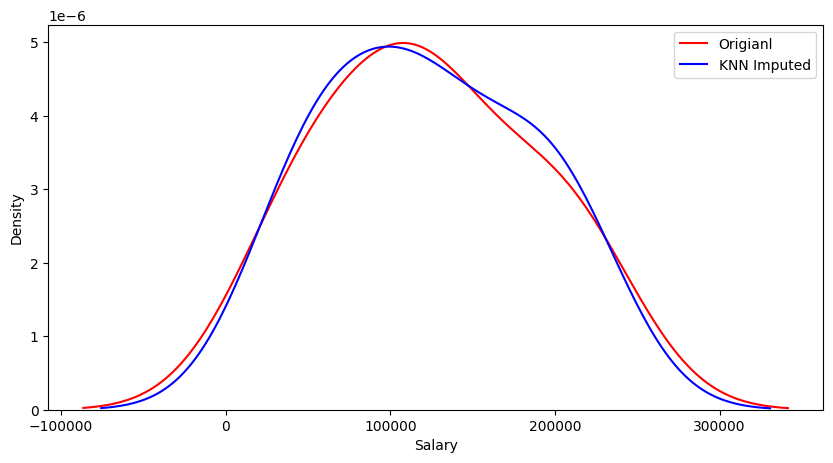

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.kdeplot(df['Salary'],label="Origianl",color='red')
sns.kdeplot(final_df['Salary'],label="KNN Imputed",color='blue')
plt.legend()
plt.show()

<h1><strong>Iterative Imputer</strong></h1>

The iterative imputer builds actual mathematical models (like regressions or trees) to estimates values. It is generally more robust for complex datasets where the relationships between variables are linear or follow specific patterns

- Initialization: Fill all missing values with a place holder (usually mean or median of the column)
- Target Selection: Pick one feature(Feature A) that has missing values. This becomes our y.
- Regression Training: Treat all features (B,C,D) as predicators(X). Train the model using only the rows where feature A is not missing
- Prediction: Use the model to predict the missing values in Feature A.
- Sequential Cycle: Repeat this for every feature that has missing Values.
- Iteration:  

In [23]:
import pandas as pd
import numpy as np

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import StandardScaler


In [17]:
np.random.seed(42)

age = np.random.randint(20,60,100)
income = (age * 2000) + np.random.normal(0,5000,100)
df = pd.DataFrame({'Age':age,"Income":income})

In [18]:
df.iloc[1:10,0] = np.nan
df.iloc[50:60,1] = np.nan

In [19]:
df

,Age,Income
0,58.0,115111.339394
1,NaN,93948.083457
2,NaN,73898.581724
3,NaN,49508.960303
4,NaN,84173.977096
...,...,...
95,28.0,61953.636281
96,27.0,60496.984071
97,31.0,57664.269220
98,53.0,109088.204228


In [20]:
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df),columns=df.columns)

In [21]:
df_scaled

,Age,Income
0,1.641162,1.547841
1,NaN,0.659227
2,NaN,-0.182623
3,NaN,-1.206708
4,NaN,0.248826
...,...,...
95,-0.924916,-0.684174
96,-1.010452,-0.745337
97,-0.668308,-0.864278
98,1.213482,1.294939


In [29]:
from sklearn.ensemble import RandomForestRegressor
it_imputer = IterativeImputer(
    max_iter=5,
    random_state=42,
    estimator=RandomForestRegressor(n_estimators=10))

df_imputed_scaled = it_imputer.fit_transform(df_scaled)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [30]:
df_final = pd.DataFrame(scaler.inverse_transform(df_imputed_scaled),columns=df.columns)

In [31]:
df_final

,Age,Income
0,58.0,115111.339394
1,47.5,93948.083457
2,38.0,73898.581724
3,26.0,49508.960303
4,43.0,84173.977096
...,...,...
95,28.0,61953.636281
96,27.0,60496.984071
97,31.0,57664.269220
98,53.0,109088.204228
